# Baseline Experiment - Binary Classification - BERT

Apply BERT to classify whether a tweet is relevant to a disater or not, in other word, binary classification.

## A. Setup

In [ ]:
%pip install transformers torch tqdm datasets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
# import os

# from dotenv import load_dotenv
# load_dotenv()

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification

import configuration
from src import setup, data_utils, hf_utils
from src.models import bert

/home/ubuntu/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_frac = data_utils.DATA_FRACTION

# https://huggingface.co/google-bert/bert-base-uncased
# bert-base-uncased - 110M
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

device = setup.setup_device_with_seeds()

batch_size = 32
learning_rate = 1e-5
num_epochs = 10
patience = 3  # early stopping, if validation loss does not improve for this many epochs

bert_base = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2  # e.g., binary sentiment
)
bert_base.config.problem_type = "single_label_classification"
# Optimizer
optimizer = AdamW(bert_base.parameters(), lr=learning_rate)

base_configs = {
    "batch_size": batch_size,
    "bert": bert_base,
    "optimizer": optimizer,
    "device": device,
    "num_epochs": num_epochs,
    "patience": patience
}

GPU: NVIDIA A100-SXM4-80GB
Memory allocated: 0.0 GB
Memory cached: 0.0 GB
Using device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3115.10it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [ ]:
def run_experiment(weather_ratio, out_topic_ratio):
    
    df_train, df_val, df_test = data_utils.load_BERT_sets(
        weather_ratio=weather_ratio, out_topic_ratio=out_topic_ratio
    )
    
    # # ====
    # # Comment out this cell to use the full dataset. This is just for quick testing.
    # train_size = 1000
    # val_size = int(train_size * len(df_val) / len(df_train))
    # test_size = int(train_size * len(df_test) / len(df_train))

    # df_train = df_train.sample(n=train_size, random_state=setup.RANDOM_SEED)
    # df_val = df_val.sample(n=val_size, random_state=setup.RANDOM_SEED)
    # df_test = df_test.sample(n=test_size, random_state=setup.RANDOM_SEED)
    # # ----

    ds_train, ds_val, ds_test = hf_utils.create_datasets(df_train, df_val, df_test)

    # Calculate the maximum length of the tokenized tweets in the training set to set the max_length parameter for BERT
    hf_utils.max_length_dist(df_train, "tweet_text", tokenizer)

    # Tokenize the datasets and save the tokenized versions.
    token_path = Path(
        f"../tokens/BERT/{data_utils.get_experiment_ratios_path(weather_ratio, out_topic_ratio)}"
    )
    train_tokenized, val_tokenized, test_tokenized = hf_utils.load_or_tokenize(
        ds_train,
        ds_val,
        ds_test,
        tokenizer,
        token_path,
        force_retokenize=True,
        format_dataset=bert.format_dataset,
    )
    
    imbalance_strategy = bert.detect_imbalance_strategy(df_train["informative"])
    print(f"Detected imbalance strategy: {imbalance_strategy}")
    
    configs = {**base_configs, **imbalance_strategy}

    # Fine-tune BERT
    model, train_loss_history, val_loss_history, val_f1_history, val_recall_history, val_precision_history = bert.finetune(
        train_tokenized, val_tokenized, configs
    )

    # Visualize training history
    hf_utils.plot_fine_tune_history(
        train_loss_history, val_loss_history, val_f1_history, val_recall_history, val_precision_history
    )

    predictions = bert.predict(model, test_tokenized, device)
    bert.report_metrics(test_tokenized, predictions)
    hf_utils.group_report_metrics(
        df_test, predictions, group_by="subset", labels="informative"
    )

Processing dataset with weather_ratio=0 and out_topic_ratio=0...


90th percentile: 50.0
95th percentile: 56.0
99th percentile: 72.50999999999999
Absolute Maximum length: 136
Tokenizing datasets...


Map: 100%|██████████| 1438/1438 [00:00<00:00, 12533.94 examples/s]


Saving tokenized datasets to ../tokens/BERT/w0_o0/1.0...


Saving the dataset (1/1 shards): 100%|██████████| 1438/1438 [00:00<00:00, 135069.85 examples/s]


...

Epoch 5/10 | Train Loss: 0.1070 | Val Loss: 0.6130 | Val Macro F1: 0.8259 | Val Recall: 0.8216 | Val Precision: 0.8316


Validating Epoch 6/10: 100%|██████████| 45/45 [00:01<00:00, 29.35it/s]


Epoch 6/10 | Train Loss: 0.0653 | Val Loss: 0.7313 | Val Macro F1: 0.8286 | Val Recall: 0.8227 | Val Precision: 0.8374


Validating Epoch 7/10: 100%|██████████| 45/45 [00:01<00:00, 30.43it/s]


Epoch 7/10 | Train Loss: 0.0485 | Val Loss: 0.8000 | Val Macro F1: 0.8287 | Val Recall: 0.8230 | Val Precision: 0.8371
Early stopping triggered at epoch 7. Best Val Recall: 0.8357
Loaded best model with Val Recall: 0.8357


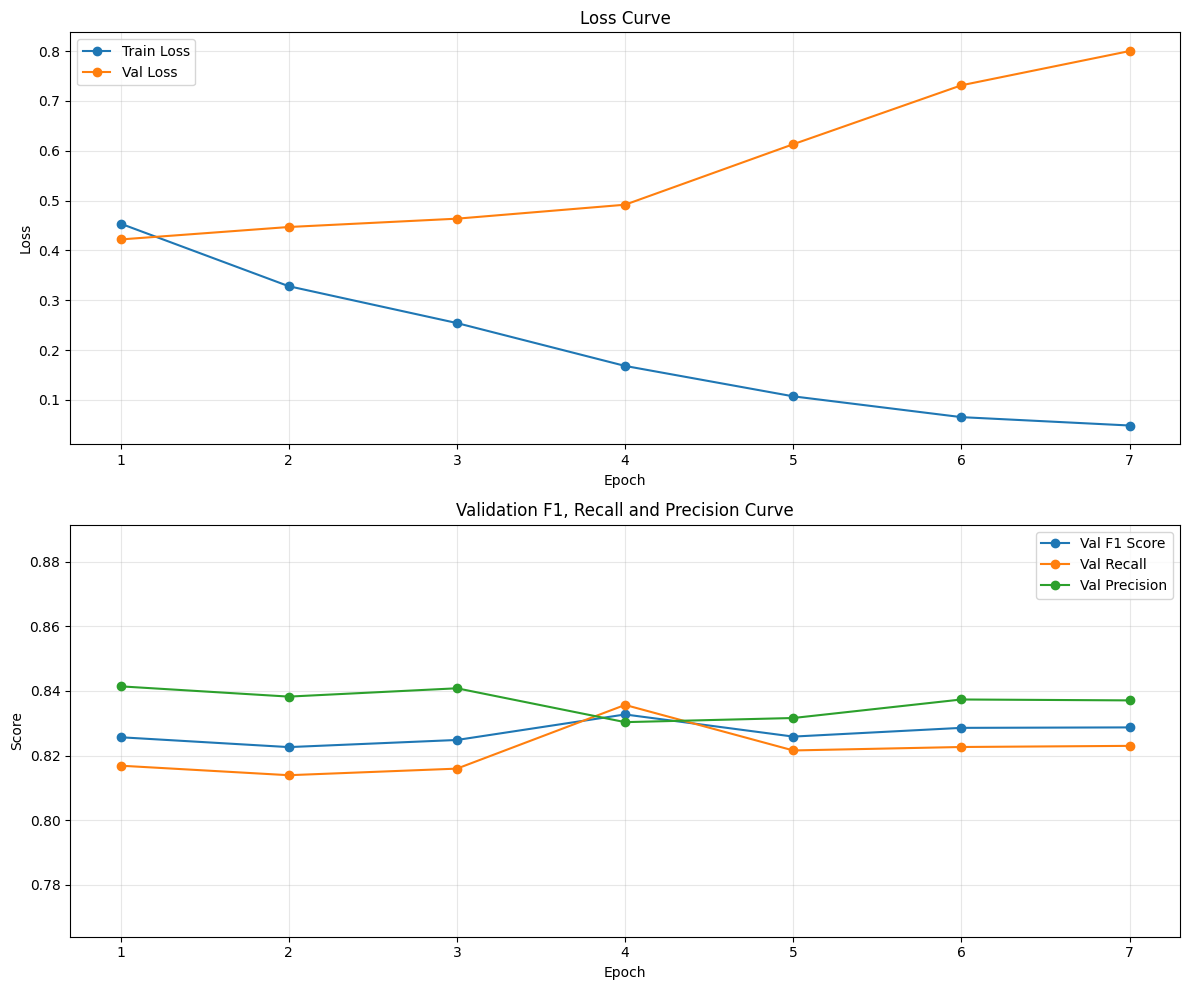

Predicting on Test Set: 100%|██████████| 90/90 [00:01<00:00, 52.98it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.7639    0.8015    0.7822       549
        True     0.8735    0.8470    0.8601       889

    accuracy                         0.8296      1438
   macro avg     0.8187    0.8242    0.8212      1438
weighted avg     0.8317    0.8296    0.8304      1438

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.7639    0.8015    0.7822       549
        True     0.8735    0.8470    0.8601       889

    accuracy                         0.8296      1438
   macro avg     0.8187    0.8242    0.8212      1438
weighted avg     0.8317    0.8296    0.8304      1438

Processing dataset with weather_ratio=1 and out_topic_ratio=0...
90th percentile: 51.0
95th percentile: 57.0
99th percentile: 69.45000000000005
Absolute Maximum length: 361
Tokenizing datasets...


Map: 100%|██████████| 1696/1696 [00:00<00:00, 12387.34 examples/s]


Saving tokenized datasets to ../tokens/BERT/w1_o0/1.0...


Saving the dataset (1/1 shards): 100%|██████████| 1696/1696 [00:00<00:00, 146360.09 examples/s]


...

Epoch 2/10 | Train Loss: 0.1083 | Val Loss: 0.1439 | Val Macro F1: 0.9592 | Val Recall: 0.9591 | Val Precision: 0.9593


Validating Epoch 3/10: 100%|██████████| 53/53 [00:01<00:00, 30.40it/s]


Epoch 3/10 | Train Loss: 0.0679 | Val Loss: 0.1568 | Val Macro F1: 0.9557 | Val Recall: 0.9558 | Val Precision: 0.9556


Validating Epoch 4/10: 100%|██████████| 53/53 [00:01<00:00, 31.00it/s]


Epoch 4/10 | Train Loss: 0.0494 | Val Loss: 0.1847 | Val Macro F1: 0.9503 | Val Recall: 0.9499 | Val Precision: 0.9508
Early stopping triggered at epoch 4. Best Val Recall: 0.9593
Loaded best model with Val Recall: 0.9593


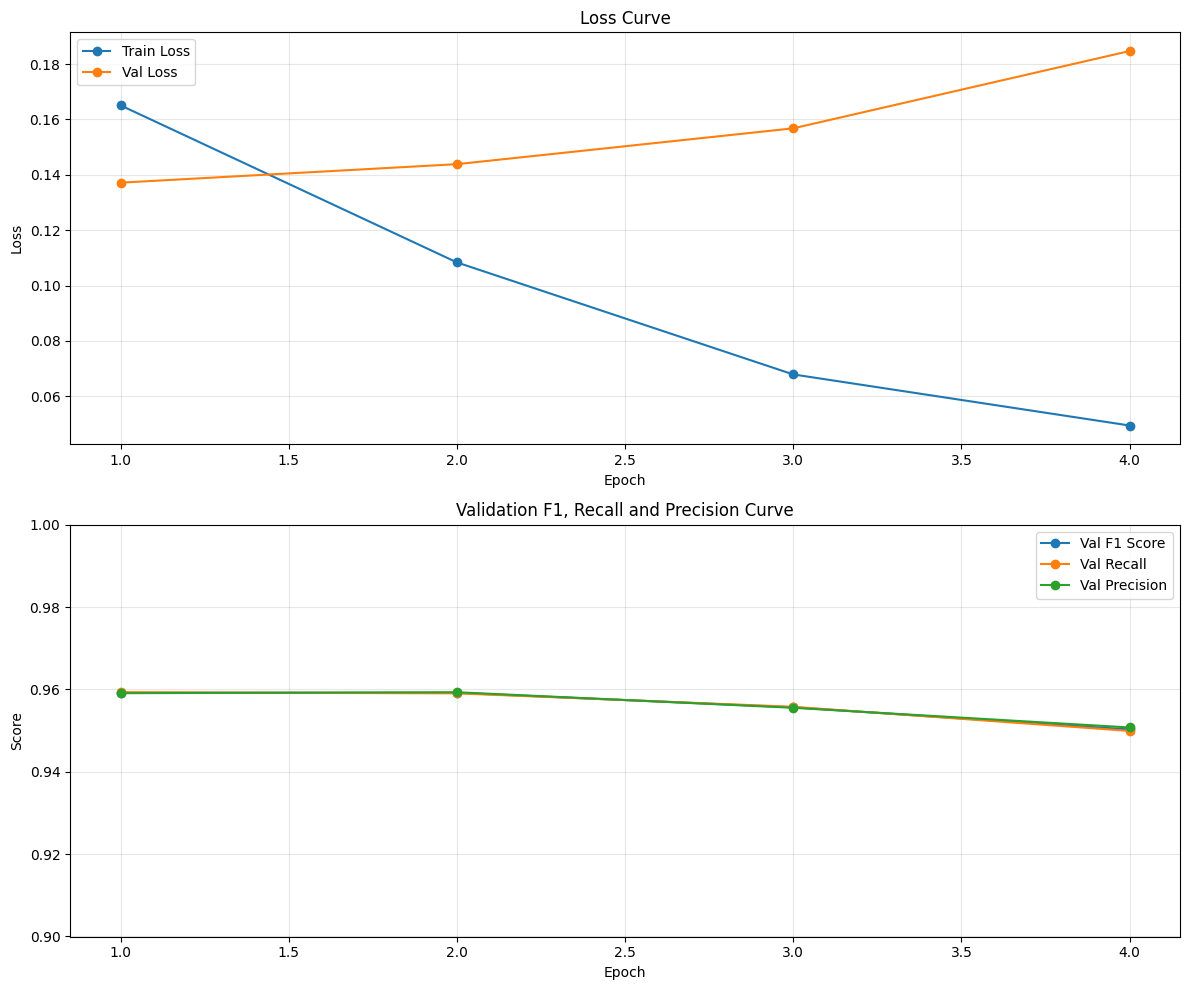

Predicting on Test Set: 100%|██████████| 106/106 [00:01<00:00, 53.93it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9509    0.9368    0.9438       807
        True     0.9434    0.9561    0.9497       889

    accuracy                         0.9469      1696
   macro avg     0.9472    0.9465    0.9468      1696
weighted avg     0.9470    0.9469    0.9469      1696

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9276    0.9141    0.9208       547
        True     0.9476    0.9561    0.9518       889

    accuracy                         0.9401      1436
   macro avg     0.9376    0.9351    0.9363      1436
weighted avg     0.9400    0.9401    0.9400      1436

 Classification Report for Subset: weather
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9846    0.9922       260
           1     0.0000 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


90th percentile: 46.0
95th percentile: 51.0
99th percentile: 65.0
Absolute Maximum length: 137
Tokenizing datasets...


Map: 100%|██████████| 3215/3215 [00:00<00:00, 6394.75 examples/s] 


...

Epoch 2/10 | Train Loss: 0.0652 | Val Loss: 0.0756 | Val Macro F1: 0.9668 | Val Recall: 0.9757 | Val Precision: 0.9589


Validating Epoch 3/10: 100%|██████████| 101/101 [00:03<00:00, 30.91it/s]


Epoch 3/10 | Train Loss: 0.0433 | Val Loss: 0.0835 | Val Macro F1: 0.9653 | Val Recall: 0.9749 | Val Precision: 0.9569


Validating Epoch 4/10: 100%|██████████| 101/101 [00:03<00:00, 30.80it/s]


Epoch 4/10 | Train Loss: 0.0312 | Val Loss: 0.0955 | Val Macro F1: 0.9621 | Val Recall: 0.9736 | Val Precision: 0.9521
Early stopping triggered at epoch 4. Best Val Recall: 0.9785
Loaded best model with Val Recall: 0.9785


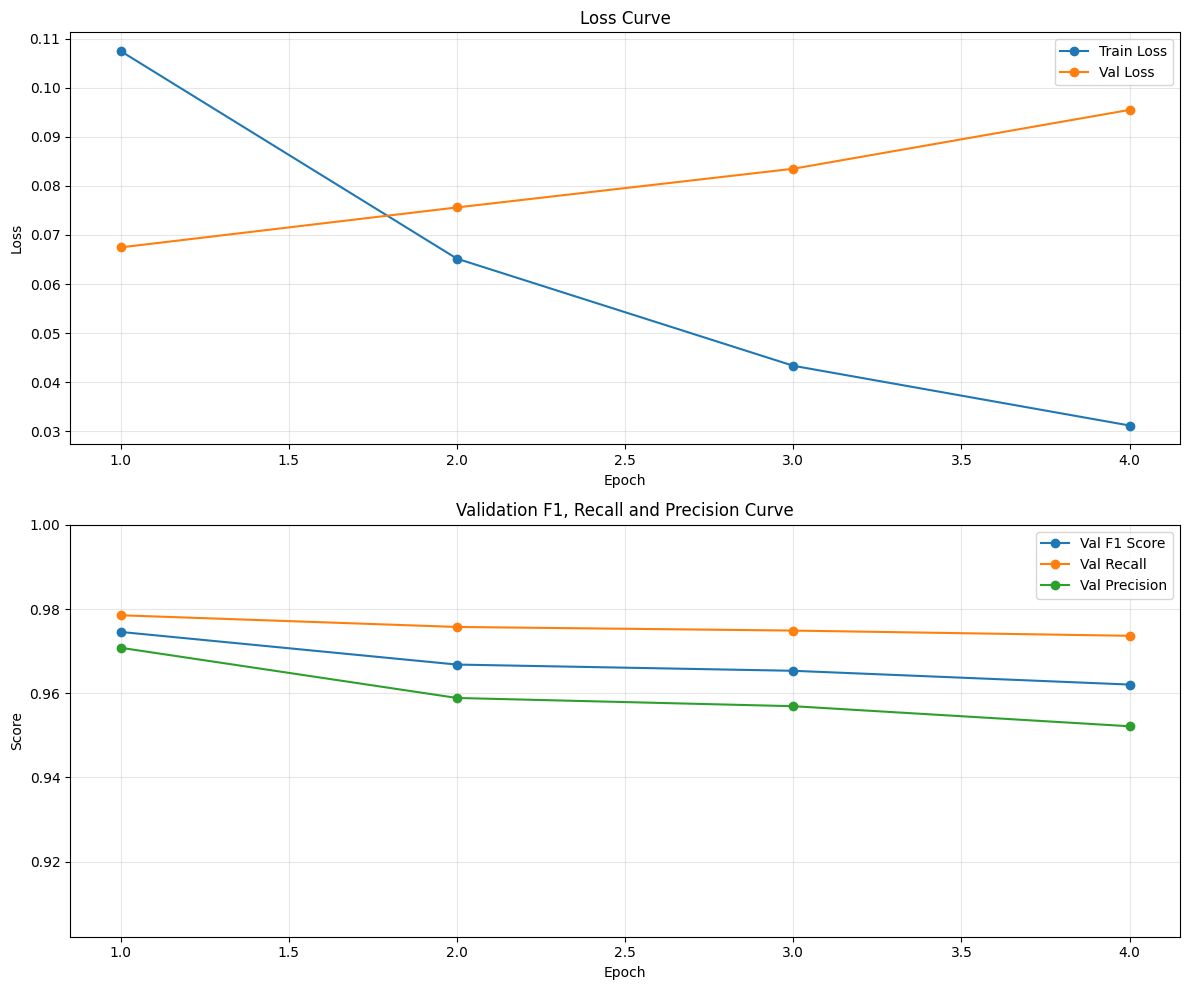

Predicting on Test Set: 100%|██████████| 201/201 [00:03<00:00, 55.48it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9900    0.9738    0.9818      2327
        True     0.9341    0.9741    0.9537       888

    accuracy                         0.9739      3215
   macro avg     0.9620    0.9739    0.9677      3215
weighted avg     0.9745    0.9739    0.9740      3215

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9563    0.9367    0.9464       537
        True     0.9622    0.9741    0.9681       888

    accuracy                         0.9600      1425
   macro avg     0.9592    0.9554    0.9572      1425
weighted avg     0.9600    0.9600    0.9599      1425

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9897    0.9948      1557
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

90th percentile: 45.80000000000018
95th percentile: 50.0
99th percentile: 63.179999999999836
Absolute Maximum length: 162
Tokenizing datasets...


Map: 100%|██████████| 4104/4104 [00:00<00:00, 6912.50 examples/s]


...

Epoch 4/10 | Train Loss: 0.0244 | Val Loss: 0.0789 | Val Macro F1: 0.9693 | Val Recall: 0.9779 | Val Precision: 0.9613


Validating Epoch 5/10: 100%|██████████| 129/129 [00:04<00:00, 29.94it/s]


Epoch 5/10 | Train Loss: 0.0153 | Val Loss: 0.0868 | Val Macro F1: 0.9614 | Val Recall: 0.9770 | Val Precision: 0.9478


Validating Epoch 6/10: 100%|██████████| 129/129 [00:04<00:00, 29.96it/s]


Epoch 6/10 | Train Loss: 0.0148 | Val Loss: 0.1070 | Val Macro F1: 0.9567 | Val Recall: 0.9744 | Val Precision: 0.9416
Early stopping triggered at epoch 6. Best Val Recall: 0.9810
Loaded best model with Val Recall: 0.9810


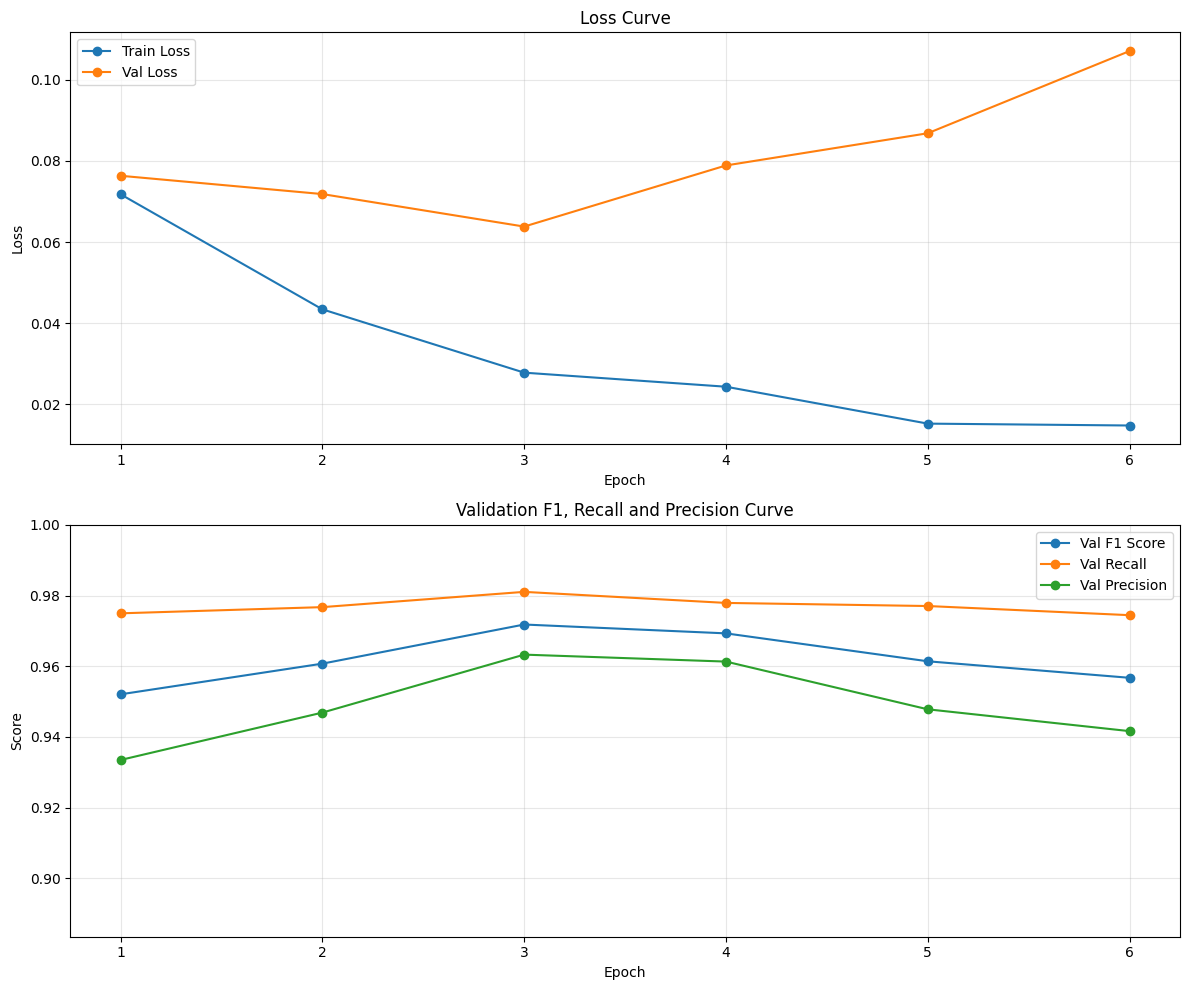

Predicting on Test Set: 100%|██████████| 257/257 [00:04<00:00, 55.10it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9962    0.9826    0.9894      3215
        True     0.9400    0.9865    0.9627       889

    accuracy                         0.9834      4104
   macro avg     0.9681    0.9845    0.9760      4104
weighted avg     0.9840    0.9834    0.9836      4104

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9781    0.9405    0.9589       571
        True     0.9627    0.9865    0.9744       889

    accuracy                         0.9685      1460
   macro avg     0.9704    0.9635    0.9667      1460
weighted avg     0.9687    0.9685    0.9684      1460

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9917    0.9958      2409
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

90th percentile: 44.0
95th percentile: 49.0
99th percentile: 61.970000000000255
Absolute Maximum length: 783
Tokenizing datasets...


Map: 100%|██████████| 5881/5881 [00:00<00:00, 13032.32 examples/s]


...

Epoch 3/10 | Train Loss: 0.0245 | Val Loss: 0.0302 | Val Macro F1: 0.9818 | Val Recall: 0.9912 | Val Precision: 0.9730


Validating Epoch 4/10: 100%|██████████| 184/184 [00:06<00:00, 30.30it/s]


Epoch 4/10 | Train Loss: 0.0228 | Val Loss: 0.0284 | Val Macro F1: 0.9849 | Val Recall: 0.9903 | Val Precision: 0.9797


Validating Epoch 5/10: 100%|██████████| 184/184 [00:06<00:00, 29.82it/s]


Epoch 5/10 | Train Loss: 0.0192 | Val Loss: 0.0354 | Val Macro F1: 0.9799 | Val Recall: 0.9901 | Val Precision: 0.9703
Early stopping triggered at epoch 5. Best Val Recall: 0.9920
Loaded best model with Val Recall: 0.9920


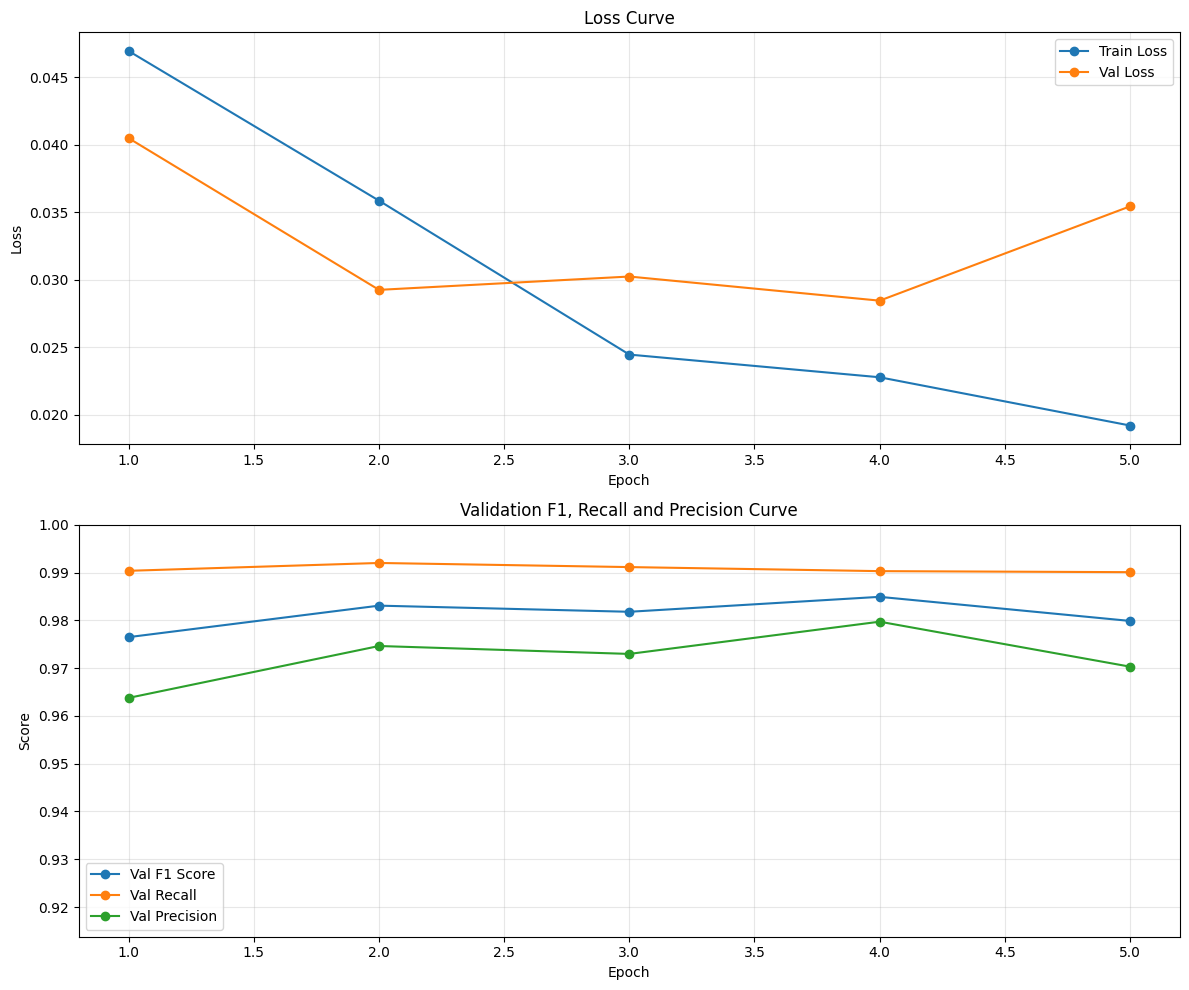

Predicting on Test Set: 100%|██████████| 368/368 [00:06<00:00, 54.98it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9996    0.9894    0.9945      4993
        True     0.9436    0.9977    0.9699       888

    accuracy                         0.9906      5881
   macro avg     0.9716    0.9936    0.9822      5881
weighted avg     0.9911    0.9906    0.9908      5881

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9960    0.9435    0.9691       531
        True     0.9672    0.9977    0.9823       888

    accuracy                         0.9774      1419
   macro avg     0.9816    0.9706    0.9757      1419
weighted avg     0.9780    0.9774    0.9773      1419

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9945    0.9973      4209
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


90th percentile: 43.0
95th percentile: 48.0
99th percentile: 58.0
Absolute Maximum length: 7685
Tokenizing datasets...


Map: 100%|██████████| 10324/10324 [00:01<00:00, 10215.66 examples/s]


...

Epoch 2/10 | Train Loss: 0.0199 | Val Loss: 0.0229 | Val Macro F1: 0.9800 | Val Recall: 0.9944 | Val Precision: 0.9665


Validating Epoch 3/10: 100%|██████████| 323/323 [00:10<00:00, 29.73it/s]


Epoch 3/10 | Train Loss: 0.0164 | Val Loss: 0.0150 | Val Macro F1: 0.9864 | Val Recall: 0.9946 | Val Precision: 0.9785


Validating Epoch 4/10: 100%|██████████| 323/323 [00:10<00:00, 29.96it/s]


Epoch 4/10 | Train Loss: 0.0123 | Val Loss: 0.0229 | Val Macro F1: 0.9837 | Val Recall: 0.9925 | Val Precision: 0.9752
Early stopping triggered at epoch 4. Best Val Recall: 0.9959
Loaded best model with Val Recall: 0.9959


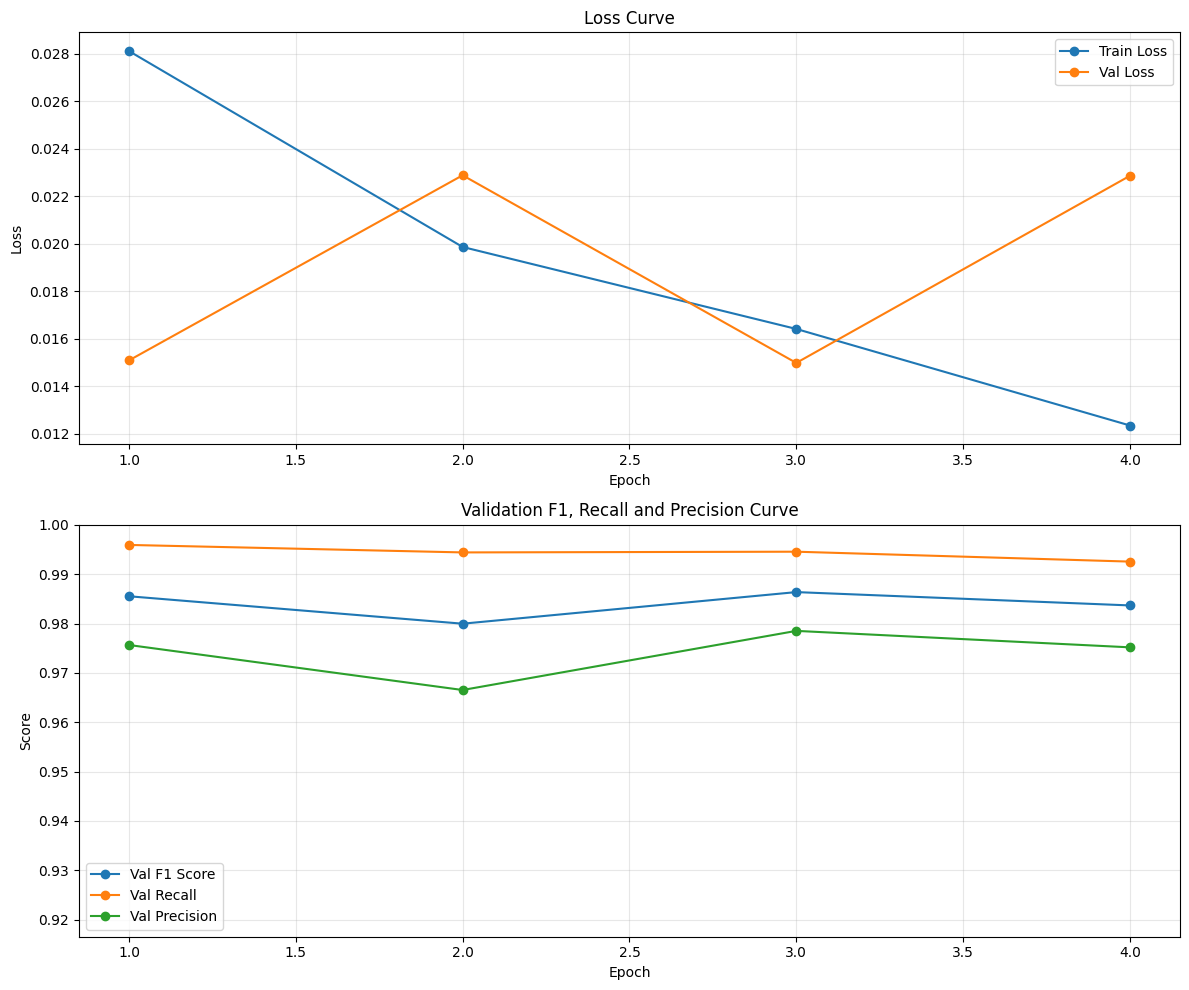

Predicting on Test Set: 100%|██████████| 646/646 [00:11<00:00, 56.94it/s]



Classification report:
              precision    recall  f1-score   support

       False     1.0000    0.9937    0.9969      9435
        True     0.9378    1.0000    0.9679       889

    accuracy                         0.9943     10324
   macro avg     0.9689    0.9969    0.9824     10324
weighted avg     0.9946    0.9943    0.9944     10324

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     1.0000    0.9603    0.9798       504
        True     0.9780    1.0000    0.9889       889

    accuracy                         0.9856      1393
   macro avg     0.9890    0.9802    0.9843      1393
weighted avg     0.9860    0.9856    0.9856      1393

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9955    0.9977      8681
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


90th percentile: 43.0
95th percentile: 47.0
99th percentile: 56.0
Absolute Maximum length: 3088
Tokenizing datasets...


Map: 100%|██████████| 14767/14767 [00:01<00:00, 10534.71 examples/s]


...

Epoch 5/10 | Train Loss: 0.0081 | Val Loss: 0.0150 | Val Macro F1: 0.9829 | Val Recall: 0.9890 | Val Precision: 0.9769


Validating Epoch 6/10: 100%|██████████| 462/462 [00:15<00:00, 30.18it/s]


Epoch 6/10 | Train Loss: 0.0066 | Val Loss: 0.0208 | Val Macro F1: 0.9745 | Val Recall: 0.9900 | Val Precision: 0.9601


Validating Epoch 7/10: 100%|██████████| 462/462 [00:15<00:00, 28.99it/s]


Epoch 7/10 | Train Loss: 0.0061 | Val Loss: 0.0224 | Val Macro F1: 0.9772 | Val Recall: 0.9893 | Val Precision: 0.9658
Early stopping triggered at epoch 7. Best Val Recall: 0.9955
Loaded best model with Val Recall: 0.9955


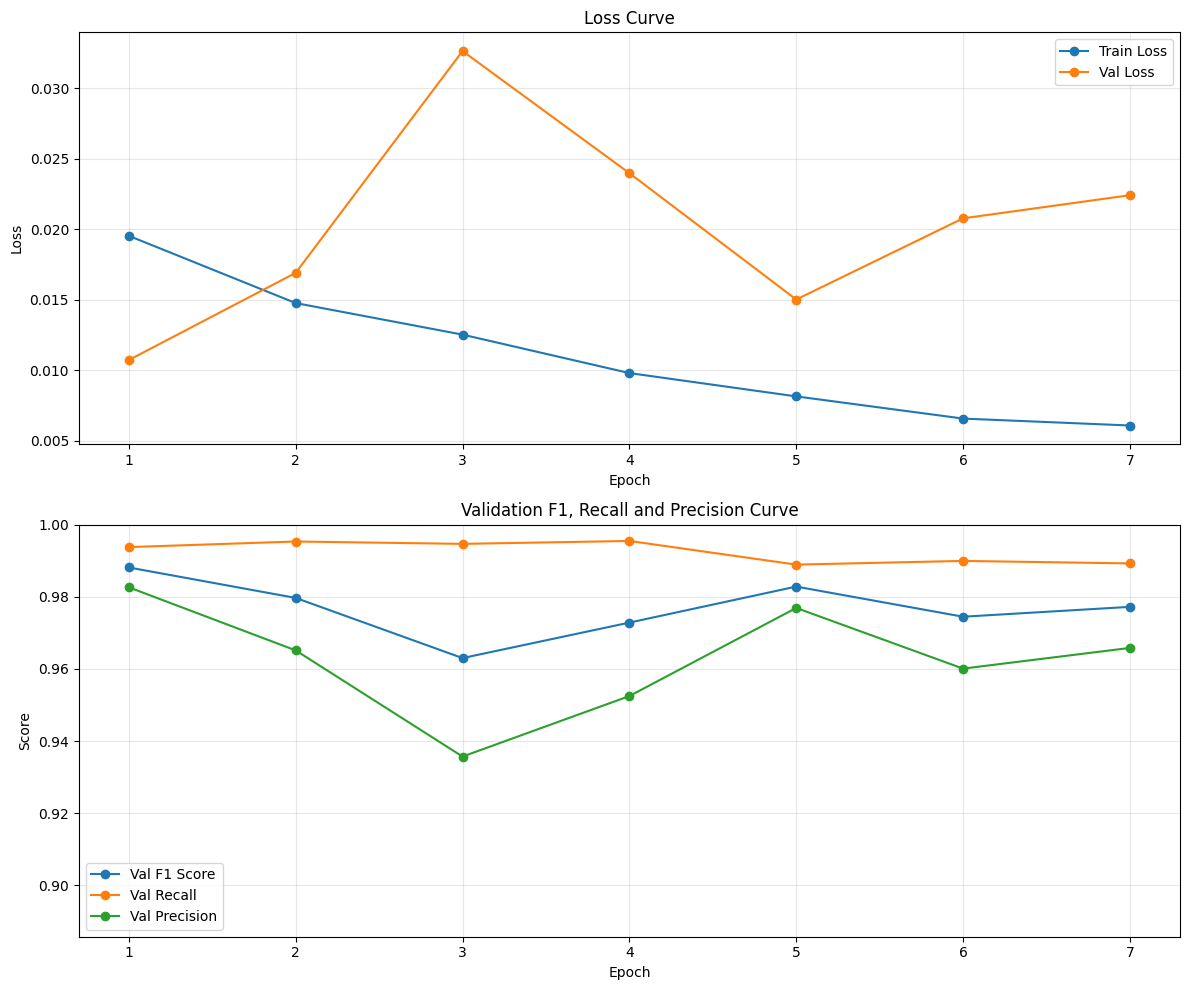

Predicting on Test Set: 100%|██████████| 923/923 [00:17<00:00, 53.86it/s]



Classification report:
              precision    recall  f1-score   support

       False     0.9999    0.9931    0.9965     13879
        True     0.9023    0.9989    0.9482       888

    accuracy                         0.9934     14767
   macro avg     0.9511    0.9960    0.9723     14767
weighted avg     0.9941    0.9934    0.9936     14767

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     0.9980    0.9147    0.9545       539
        True     0.9507    0.9989    0.9742       888

    accuracy                         0.9671      1427
   macro avg     0.9743    0.9568    0.9643      1427
weighted avg     0.9686    0.9671    0.9668      1427

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9963    0.9981     13091
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_clas

90th percentile: 42.0
95th percentile: 47.0
99th percentile: 56.0
Absolute Maximum length: 3088
Tokenizing datasets...


Map: 100%|██████████| 19210/19210 [00:01<00:00, 11153.80 examples/s]


...

Epoch 2/10 | Train Loss: 0.0028 | Val Loss: 0.0018 | Val Macro F1: 0.9890 | Val Recall: 0.9984 | Val Precision: 0.9800


Validating Epoch 3/10: 100%|██████████| 601/601 [00:20<00:00, 28.75it/s]


Epoch 3/10 | Train Loss: 0.0023 | Val Loss: 0.0023 | Val Macro F1: 0.9873 | Val Recall: 0.9967 | Val Precision: 0.9783


Validating Epoch 4/10: 100%|██████████| 601/601 [00:20<00:00, 29.47it/s]


Epoch 4/10 | Train Loss: 0.0022 | Val Loss: 0.0024 | Val Macro F1: 0.9809 | Val Recall: 0.9971 | Val Precision: 0.9658
Early stopping triggered at epoch 4. Best Val Recall: 0.9984
Loaded best model with Val Recall: 0.9984


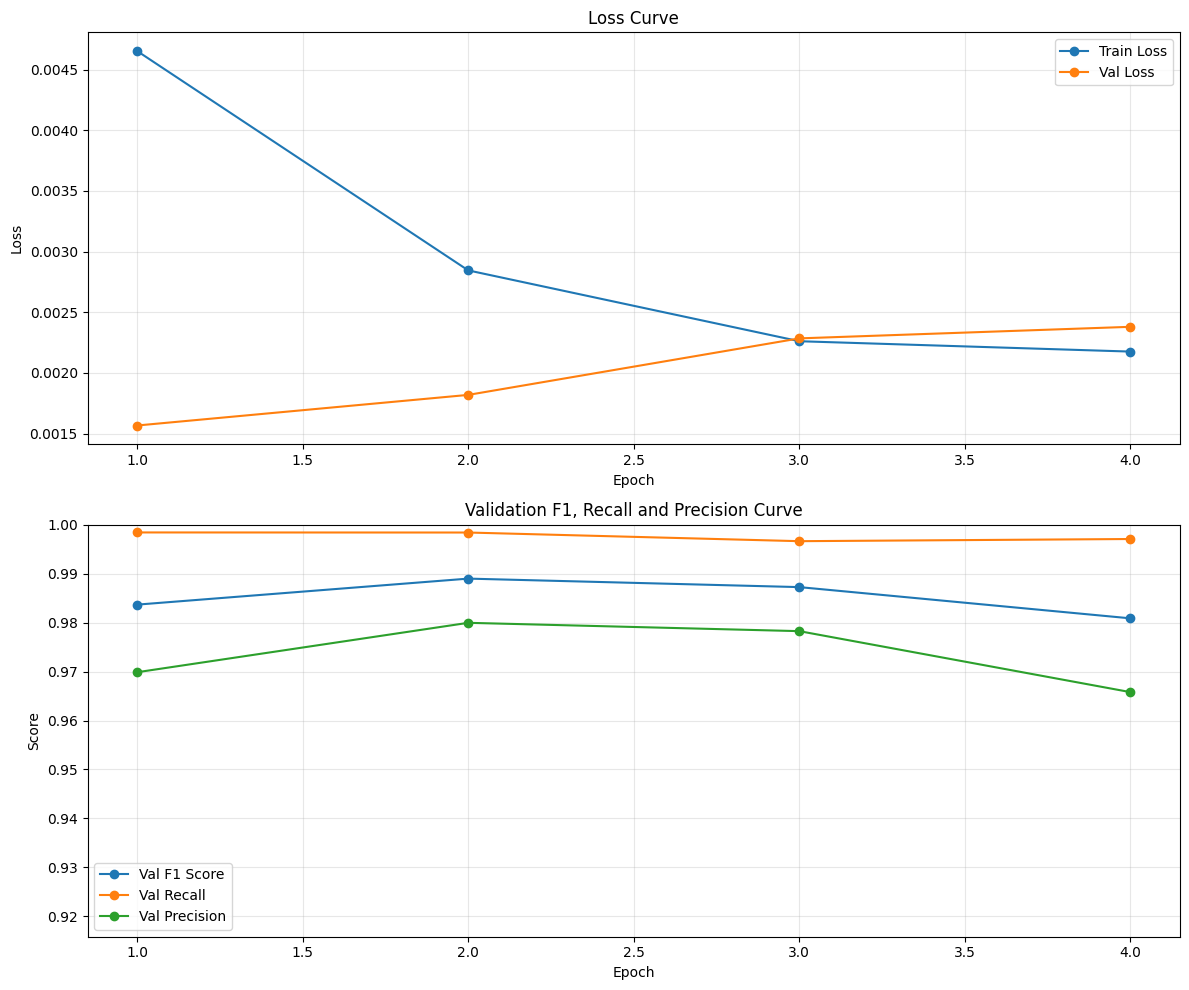

Predicting on Test Set: 100%|██████████| 1201/1201 [00:21<00:00, 55.25it/s]



Classification report:
              precision    recall  f1-score   support

       False     1.0000    0.9979    0.9989     18322
        True     0.9579    1.0000    0.9785       888

    accuracy                         0.9980     19210
   macro avg     0.9790    0.9989    0.9887     19210
weighted avg     0.9981    0.9980    0.9980     19210

 Classification Report for Subset: disaster
--------------------------------------------------
              precision    recall  f1-score   support

       False     1.0000    0.9744    0.9870       507
        True     0.9856    1.0000    0.9927       888

    accuracy                         0.9907      1395
   macro avg     0.9928    0.9872    0.9899      1395
weighted avg     0.9908    0.9907    0.9907      1395

 Classification Report for Subset: out_topic
--------------------------------------------------
              precision    recall  f1-score   support

           0     1.0000    0.9985    0.9993     17569
           1     0.000

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [4]:
for weather_ratio, out_topic_ratio in data_utils.EXPERIMENT_RATIOS:
    print(
        f"Processing dataset with weather_ratio={weather_ratio} and out_topic_ratio={out_topic_ratio}..."
    )
    run_experiment(weather_ratio, out_topic_ratio)